# Workshop: Generative AI with Diffusion Models
## Part 2: Reverse Diffusion and Optimizations

Practical session (60 min)

This notebook is part of a workshop based on NVIDIA DLI materials
"Generative AI with Diffusion Models",
adapted for Google Colab with a T4 GPU.

Credits: Original course materials by NVIDIA Corporation / NVIDIA Deep Learning Institute.

### Learning Objectives

By the end of this notebook you will be able to:

- Implement the reverse diffusion process and generate images from noise
- Explain and fix the checkerboard artifact caused by transposed convolution
- Replace MaxPool with RearrangePoolBlock to avoid information loss
- Use sinusoidal positional embeddings for richer time encoding
- Add residual connections for better gradient flow in deeper networks
- Compare image quality: basic model vs. fully optimized model

In [2]:
!pip install -q torch torchvision matplotlib numpy einops

In [3]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from einops.layers.torch import Rearrange

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

Device: cuda
GPU   : Tesla T4


---

## Part 2.1: Recap from Part 1

Run these cells to restore the dataset and noise schedule from Part 1.
The code is identical to Part 1; it is repeated here because the kernel was restarted.

In [4]:
# Dataset and constants
IMG_SIZE   = 16
IMG_CH     = 1
BATCH_SIZE = 128

data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])
train_set  = torchvision.datasets.FashionMNIST('./data', download=True, train=True,  transform=data_transforms)
test_set   = torchvision.datasets.FashionMNIST('./data', download=True, train=False, transform=data_transforms)
data       = torch.utils.data.ConcatDataset([train_set, test_set])
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Noise schedule
T      = 300
B      = torch.linspace(0.0001, 0.02, T).to(device)
a      = 1.0 - B
a_bar  = torch.cumprod(a, dim=0)
sqrt_a_bar           = torch.sqrt(a_bar)
sqrt_one_minus_a_bar = torch.sqrt(1 - a_bar)
sqrt_a_inv           = torch.sqrt(1 / a)
pred_noise_coeff     = (1 - a) / sqrt_one_minus_a_bar

# Closed-form forward diffusion
def q(x_0, t):
    t = t.int()
    noise           = torch.randn_like(x_0)
    sqrt_a_bar_t    = sqrt_a_bar[t, None, None, None]
    sqrt_1m_a_bar_t = sqrt_one_minus_a_bar[t, None, None, None]
    return sqrt_a_bar_t * x_0 + sqrt_1m_a_bar_t * noise, noise

print('Dataset and noise schedule ready.')
print(f'Batches/epoch: {len(dataloader)}')

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


Dataset and noise schedule ready.
Batches/epoch: 546


In [5]:
# Basic U-Net classes from Part 1 (exact same code)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, 1, 1), nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.MaxPool2d(2),
        )
    def forward(self, x): return self.model(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(2*in_ch, out_ch, 3, 2, 1, output_padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1), nn.BatchNorm2d(out_ch), nn.ReLU(),
        )
    def forward(self, x, skip):
        return self.model(torch.cat((x, skip), dim=1))


class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.input_dim = input_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim), nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        )
    def forward(self, x): return self.model(x.view(-1, self.input_dim))


class UNetBasic(nn.Module):
    def __init__(self, T, img_ch=IMG_CH, down_chs=(16, 32, 64)):
        super().__init__()
        self.T = T
        up_chs = down_chs[::-1]
        latent_size = IMG_SIZE // 4
        self.down0 = nn.Sequential(
            nn.Conv2d(img_ch, down_chs[0], 3, 1, 1),
            nn.BatchNorm2d(down_chs[0]), nn.ReLU(),
        )
        self.down1    = DownBlock(down_chs[0], down_chs[1])
        self.down2    = DownBlock(down_chs[1], down_chs[2])
        self.to_vec   = nn.Sequential(nn.Flatten(), nn.ReLU())
        self.from_vec = nn.Sequential(
            nn.Linear(down_chs[2]*latent_size**2, down_chs[2]*latent_size**2), nn.ReLU(),
            nn.Unflatten(1, (up_chs[0], latent_size, latent_size)),
        )
        self.t_emb1 = EmbedBlock(1, up_chs[0])
        self.t_emb2 = EmbedBlock(1, up_chs[1])
        self.up1    = UpBlock(up_chs[0], up_chs[1])
        self.up2    = UpBlock(up_chs[1], up_chs[2])
        self.out    = nn.Sequential(
            nn.Conv2d(2*up_chs[-1], up_chs[-1], 3, 1, 1), nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )
    def forward(self, x, t):
        t_n   = (t.float() / self.T).view(-1, 1)
        d0    = self.down0(x)
        d1    = self.down1(d0)
        d2    = self.down2(d1)
        lat   = self.from_vec(self.to_vec(d2))
        u1    = self.up1(self.t_emb1(t_n) * lat, d2)
        u2    = self.up2(self.t_emb2(t_n) * u1,  d1)
        return self.out(torch.cat((u2, d0), dim=1))


print('Basic model classes defined.')

Basic model classes defined.


---

## Part 2.2: Reverse Diffusion

In Part 1 we trained the model to predict noise.
Now we use that prediction to go backwards: from noise to a clean image.

The reverse step formula removes the predicted noise from x_t to get x_{t-1}:

```
u_t = (1 / sqrt(a_t)) * (x_t - (1 - a_t) / sqrt(1 - a_bar_t) * predicted_noise)
```

If t > 0, we also add a small amount of noise from the previous timestep.
This keeps the generation stochastic (different each run).
If t = 0, we return u_t directly as the final clean image.

We repeat this step from t=T down to t=0, which is T=300 steps.

This computes `u_t`, the denoised estimate, by removing the predicted noise from `x_t` using the two precomputed coefficients.

In [ ]:
@torch.no_grad()
def reverse_q(x_t, t, e_t):
    """
    One step of reverse diffusion.
    x_t : noisy image at timestep t,      shape [B, C, H, W]
    t   : current timestep per sample,    shape [B] (all same value)
    e_t : predicted noise from the model, shape [B, C, H, W]
    Returns x_{t-1}: slightly less noisy image.
    """
    t_int = t.int()
    coeff       = pred_noise_coeff[t_int, None, None, None]
    sqrt_a_inv_t = sqrt_a_inv[t_int, None, None, None]
    u_t = sqrt_a_inv_t * (x_t - coeff * e_t)

    if t_int[0] == 0:
        return u_t   # final step: return clean image directly
    else:
        # add a small amount of noise for the previous timestep
        B_prev = B[t_int - 1, None, None, None]
        return u_t + torch.sqrt(B_prev) * torch.randn_like(x_t)


@torch.no_grad()
def generate(model, n=4, show_steps=True):
    """Generate n images and optionally show the denoising process for the first one."""
    # --- denoising process for 1 image ---
    if show_steps:
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
        step_size  = T // 10
        shown_imgs = []
        shown_ts   = []
        for i in range(T - 1, -1, -1):
            t_b  = torch.full((1,), i, device=device).float()
            x    = reverse_q(x, t_b, model(x, t_b))
            if i % step_size == 0:
                shown_imgs.append(x[0].clone().cpu())
                shown_ts.append(i)
        # shown_imgs/shown_ts are already in noise -> clean order:
        # the loop runs from i=T-1 down to i=0, so earlier appends are noisier
        # and later appends are cleaner. No reversal needed.
        fig, axes  = plt.subplots(1, len(shown_imgs), figsize=(14, 2))
        for ax, img, t_val in zip(axes, shown_imgs, shown_ts):
            ax.imshow(((img+1)/2).clamp(0,1).squeeze(), cmap='gray')
            ax.set_title(f't={t_val}', fontsize=7)
            ax.axis('off')
        plt.suptitle('Denoising process: noise -> clean image')
        plt.tight_layout()
        plt.show()

    # --- n final samples ---
    results = []
    for _ in range(n):
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
        for i in range(T - 1, -1, -1):
            t_b = torch.full((1,), i, device=device).float()
            x   = reverse_q(x, t_b, model(x, t_b))
        results.append(x[0])
    fig, axes = plt.subplots(1, n, figsize=(10, 2.5))
    for ax, img in zip(axes, results):
        ax.imshow(((img+1)/2).clamp(0,1).squeeze().cpu(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'{n} generated samples')
    plt.tight_layout()
    plt.show()

print('reverse_q and generate functions defined.')

### Train the Basic Model

We train the basic U-Net for 3 epochs to use as a baseline.
After training, we generate some samples to see what the basic model produces.
This shows the problems we will fix with the optimizations below.

Epoch 1/3 | loss: 0.16814
Epoch 2/3 | loss: 0.10457
Epoch 3/3 | loss: 0.09677

Basic model samples:


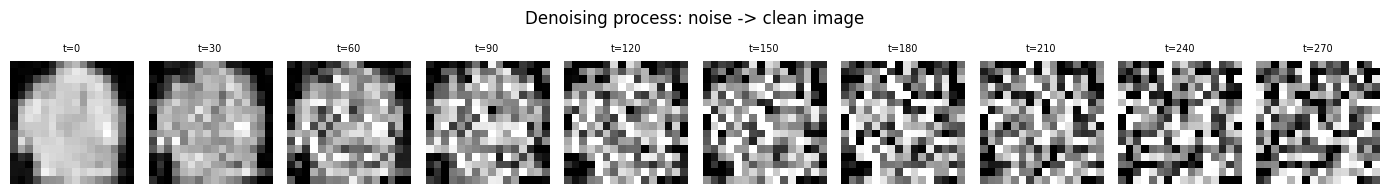

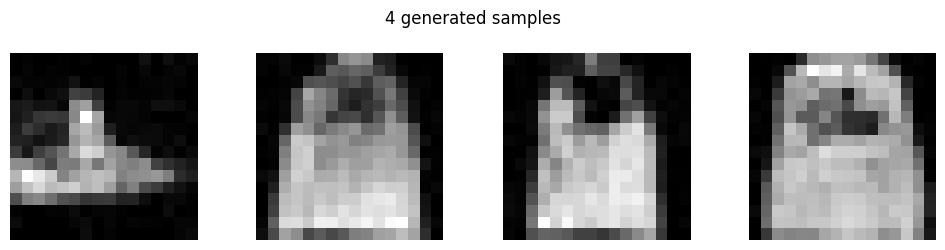

In [7]:
import gc

model_basic = UNetBasic(T).to(device)
optimizer   = Adam(model_basic.parameters(), lr=0.001)
EPOCHS      = 3

model_basic.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        x_0  = batch[0].to(device)
        t    = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
        x_noisy, noise = q(x_0, t)
        loss = F.mse_loss(noise, model_basic(x_noisy, t))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} | loss: {epoch_loss/len(dataloader):.5f}')

model_basic.eval()
print('\nBasic model samples:')
generate(model_basic, n=4, show_steps=True)

---

## Part 2.3: Four Optimizations

The basic model produces pixelated images for two main reasons:

1. **Checkerboard artifacts** from `ConvTranspose2d` with kernel=3, stride=2
2. **Limited model capacity** from a shallow per-block architecture

We fix this with four changes:

| Optimization | Replaces | What it fixes |
|---|---|---|
| GELUConvBlock | Conv + BatchNorm + ReLU | smoother gradients, better small-batch norm |
| RearrangePoolBlock | MaxPool2d | no information loss when downsampling |
| SinusoidalPositionEmbedBlock | linear t/T | richer time representation |
| ResidualConvBlock | single conv in initial block | better gradient flow, deeper network |

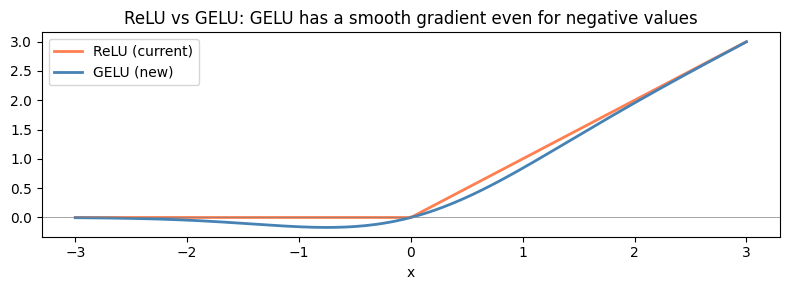

GELUConvBlock defined.


In [8]:
# --- Optimization 1: GELUConvBlock ---
# Replaces: Conv2d + BatchNorm + ReLU
# With    : Conv2d + GroupNorm + GELU

# Why GroupNorm?
# BatchNorm computes statistics across the batch dimension.
# With small batches (batch_size=1 at inference), statistics are unreliable.
# GroupNorm computes statistics within groups of channels, independent of batch size.

# Why GELU?
# ReLU sets all negative values to 0, which kills gradients for those neurons.
# GELU is smooth: it has a small non-zero gradient even for negative inputs.

x = torch.linspace(-3, 3, 200)
plt.figure(figsize=(8, 3))
plt.plot(x, torch.relu(x).numpy(),      label='ReLU (current)', color='coral',    linewidth=2)
plt.plot(x, F.gelu(x).numpy(),          label='GELU (new)',     color='steelblue', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.legend()
plt.title('ReLU vs GELU: GELU has a smooth gradient even for negative values')
plt.xlabel('x')
plt.tight_layout()
plt.show()


class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU(),
        )
    def forward(self, x): return self.model(x)


print('GELUConvBlock defined.')

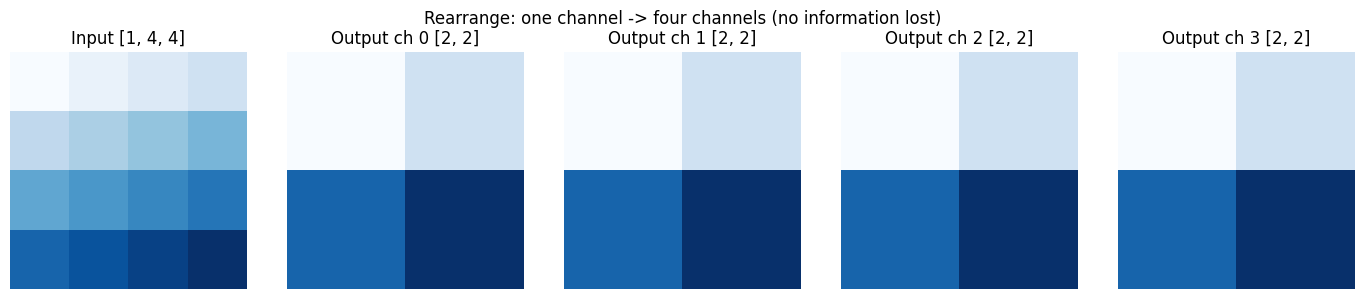

Input shape : torch.Size([1, 1, 4, 4])   (1 channel, 4x4)
Output shape: torch.Size([1, 4, 2, 2]) (4 channels, 2x2)
All 16 values are still present, just reorganized.
RearrangePoolBlock defined.


In [9]:
# --- Optimization 2: RearrangePoolBlock ---
# Replaces: MaxPool2d(2)
# With    : einops Rearrange + GELUConvBlock

# MaxPool discards 3 out of 4 pixels in each 2x2 block. Information is lost.
# RearrangePoolBlock moves spatial pixels into the channel dimension instead.
# No pixels are discarded: they are reorganized.

# Demonstration: what rearrange does to a 4x4 image
rearrange_demo = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
test = torch.arange(1, 17).float().view(1, 1, 4, 4)
result = rearrange_demo(test)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(test[0, 0].numpy(), cmap='Blues')
axes[0].set_title('Input [1, 4, 4]')
for i in range(4):
    axes[i+1].imshow(result[0, i].numpy(), cmap='Blues')
    axes[i+1].set_title(f'Output ch {i} [2, 2]')
for ax in axes:
    ax.axis('off')
plt.suptitle('Rearrange: one channel -> four channels (no information lost)')
plt.tight_layout()
plt.show()

print(f'Input shape : {test.shape}   (1 channel, 4x4)')
print(f'Output shape: {result.shape} (4 channels, 2x2)')
print('All 16 values are still present, just reorganized.')


class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size=8):
        super().__init__()
        self.rearrange = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
        # 4 * in_chs because rearrange multiplied channels by p1*p2 = 4
        self.conv = GELUConvBlock(4 * in_chs, in_chs, group_size)
    def forward(self, x):
        return self.conv(self.rearrange(x))


print('RearrangePoolBlock defined.')

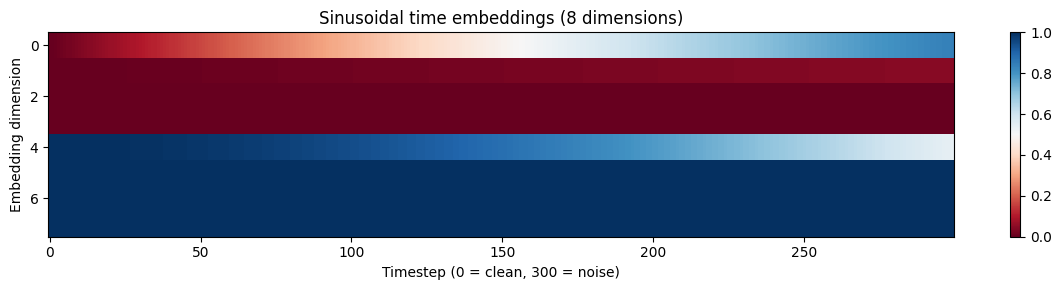

Each row is one embedding dimension.
Each column is one timestep.
The pattern of waves gives the model a rich, unique representation for each time step.


In [10]:
# --- Optimization 3: SinusoidalPositionEmbedBlock ---
# Replaces: simple linear embedding of t/T
# With    : sinusoidal encoding at multiple frequencies

# In Part 1, the time embedding was a single scalar t/T mapped through two linear layers.
# This means the model cannot easily distinguish timesteps that are far apart.
# Sinusoidal embeddings use many frequencies, like a combination of clocks.
# Each frequency captures a different scale of time information.

class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        freqs    = math.log(10000) / (half_dim - 1)
        freqs    = torch.exp(torch.arange(half_dim, device=device) * -freqs)
        angles   = t[:, None] * freqs[None, :]
        return torch.cat((angles.sin(), angles.cos()), dim=-1)


# Visualize: how each timestep is encoded
T_EMBED_DIM = 8
sin_emb_block = SinusoidalPositionEmbedBlock(T_EMBED_DIM)
t_values = torch.linspace(0, 1, T)
embeds   = sin_emb_block(t_values)   # [T, T_EMBED_DIM]

plt.figure(figsize=(12, 3))
plt.imshow(embeds.detach().T.numpy(), aspect='auto', cmap='RdBu')
plt.xlabel('Timestep (0 = clean, 300 = noise)')
plt.ylabel('Embedding dimension')
plt.title(f'Sinusoidal time embeddings ({T_EMBED_DIM} dimensions)')
plt.colorbar()
plt.tight_layout()
plt.show()

print('Each row is one embedding dimension.')
print('Each column is one timestep.')
print('The pattern of waves gives the model a rich, unique representation for each time step.')

A residual connection adds the output of the first convolution (`x1`) to the output of the second convolution (`x2`). This creates a shortcut for gradients to flow backwards during training, and lets the network learn refinements on top of an identity function.

In [11]:
# --- Optimization 4: ResidualConvBlock ---
# Replaces: single Conv in the initial down0 block
# With    : two GELUConvBlocks with a residual (skip) connection

# A residual connection adds the input of a block to its output.
# This creates a shortcut for gradients to flow backwards during training.
# It also lets the network learn refinements on top of an identity function.

class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        self.conv1 = GELUConvBlock(in_ch,  out_ch, group_size)
        self.conv2 = GELUConvBlock(out_ch, out_ch, group_size)

    def forward(self, x):
        x1 = self.conv1(x)    # first convolution
        x2 = self.conv2(x1)   # second convolution
        return x1 + x2


print('ResidualConvBlock defined.')
print('Note: the skip goes from after conv1 to after conv2, not from input to output.')
print('This means the block learns the difference between two processing steps.')

ResidualConvBlock defined.
Note: the skip goes from after conv1 to after conv2, not from input to output.
This means the block learns the difference between two processing steps.


---

## Part 2.4: The Optimized U-Net

We now put all four optimizations together into new DownBlock and UpBlock definitions,
then build the full optimized U-Net.

Key changes from Part 1:

- **DownBlock:** MaxPool -> RearrangePoolBlock, Conv+BN+ReLU -> GELUConvBlock
- **UpBlock:** `ConvTranspose2d(kernel=3, stride=2)` -> `ConvTranspose2d(kernel=2, stride=2)`
  This directly fixes the checkerboard problem (kernel=2, stride=2 produces no overlap).
  Also: 2 Conv layers -> 4 GELUConvBlock layers for more capacity.
- **Initial block:** single Conv -> ResidualConvBlock
- **Time embedding:** linear t/T -> sinusoidal -> EmbedBlock
- **Bottleneck:** one large linear layer -> compact three-layer bottleneck
- **Channel sizes:** (16, 32, 64) -> (32, 64, 128) for more capacity

In [12]:
class DownBlockOpt(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        self.model = nn.Sequential(
            GELUConvBlock(in_ch,  out_ch, group_size),
            GELUConvBlock(out_ch, out_ch, group_size),
            RearrangePoolBlock(out_ch, group_size),   # replaces MaxPool2d
        )
    def forward(self, x): return self.model(x)


class UpBlockOpt(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        self.model = nn.Sequential(
            # kernel=2, stride=2 has no overlap: no checkerboard artifacts
            nn.ConvTranspose2d(2 * in_ch, out_ch, 2, 2),
            GELUConvBlock(out_ch, out_ch, group_size),
            GELUConvBlock(out_ch, out_ch, group_size),
            GELUConvBlock(out_ch, out_ch, group_size),
            GELUConvBlock(out_ch, out_ch, group_size),
        )
    def forward(self, x, skip):
        return self.model(torch.cat((x, skip), dim=1))


print('DownBlockOpt and UpBlockOpt defined.')

DownBlockOpt and UpBlockOpt defined.


In [13]:
class EmbedBlockOpt(nn.Module):
    """Same as Part 1 EmbedBlock but uses GELU instead of ReLU."""
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.input_dim = input_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim), nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        )
    def forward(self, x): return self.model(x.view(-1, self.input_dim))


class UNetOptimized(nn.Module):
    def __init__(self, T, img_ch=IMG_CH, down_chs=(32, 64, 128), t_embed_dim=8):
        super().__init__()
        self.T   = T
        up_chs   = down_chs[::-1]       # (128, 64, 32)
        lat_size = IMG_SIZE // 4         # 4
        gs_sm    = 8                     # group size for small layers
        gs_bg    = 32                    # group size for large layers

        # Encoder
        self.down0 = ResidualConvBlock(img_ch, down_chs[0], gs_sm)
        self.down1 = DownBlockOpt(down_chs[0], down_chs[1], gs_sm)
        self.down2 = DownBlockOpt(down_chs[1], down_chs[2], gs_bg)
        self.to_vec = nn.Sequential(nn.Flatten(), nn.GELU())

        # Compact bottleneck (much smaller than Part 1's single linear layer)
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2] * lat_size**2, down_chs[1]), nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),                nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2] * lat_size**2),  nn.ReLU(),
        )

        # Sinusoidal time embeddings
        self.sintime = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_emb1  = EmbedBlockOpt(t_embed_dim, up_chs[0])
        self.t_emb2  = EmbedBlockOpt(t_embed_dim, up_chs[1])

        # Decoder
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], lat_size, lat_size)),
            GELUConvBlock(up_chs[0], up_chs[0], gs_bg),
        )
        self.up1 = UpBlockOpt(up_chs[0], up_chs[1], gs_bg)
        self.up2 = UpBlockOpt(up_chs[1], up_chs[2], gs_sm)

        # Output
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.GroupNorm(gs_sm, up_chs[-1]), nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x, t):
        t_sin = self.sintime(t.float() / self.T)
        t1    = self.t_emb1(t_sin)
        t2    = self.t_emb2(t_sin)

        d0    = self.down0(x)
        d1    = self.down1(d0)
        d2    = self.down2(d1)
        lat   = self.dense_emb(self.to_vec(d2))

        u0    = self.up0(lat)
        u1    = self.up1(t1 * u0, d2)
        u2    = self.up2(t2 * u1, d1)
        return self.out(torch.cat((u2, d0), dim=1))


model_opt3 = UNetOptimized(T).to(device)
n_basic = sum(p.numel() for p in model_basic.parameters())
n_opt   = sum(p.numel() for p in model_opt3.parameters())
print(f'Basic model params   : {n_basic:,}')
print(f'Optimized model params: {n_opt:,}')

x_test = torch.randn(2, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)
t_test = torch.tensor([50., 150.]).to(device)
print(f'Output shape: {model_opt3(x_test, t_test).shape}')

Basic model params   : 1,187,553
Optimized model params: 1,750,145
Output shape: torch.Size([2, 1, 16, 16])


Epoch 1/3 | loss: 0.12859
Epoch 2/3 | loss: 0.08630
Epoch 3/3 | loss: 0.07872

Optimized model samples:


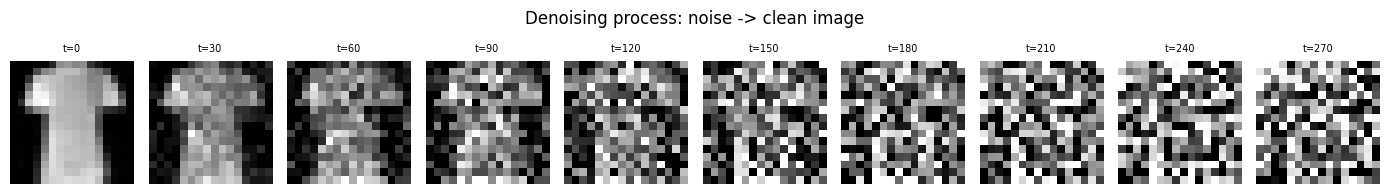

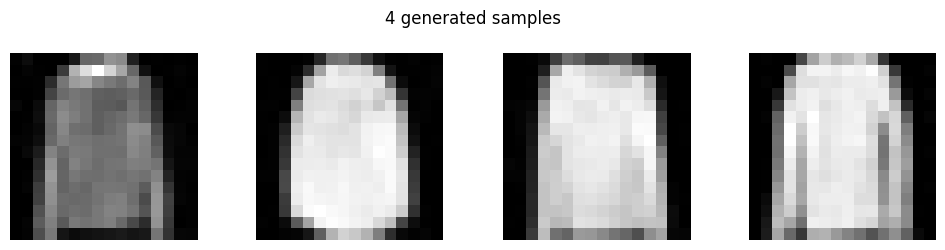

In [14]:
# Train the optimized model
# We expect better results than the basic model even in the same number of epochs

optimizer_opt = Adam(model_opt3.parameters(), lr=0.001)
EPOCHS = 3

model_opt3.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for step, batch in enumerate(dataloader):
        optimizer_opt.zero_grad()
        x_0  = batch[0].to(device)
        t    = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
        x_noisy, noise = q(x_0, t)
        loss = F.mse_loss(noise, model_opt3(x_noisy, t))
        loss.backward()
        optimizer_opt.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} | loss: {epoch_loss/len(dataloader):.5f}')

model_opt3.eval()
print('\nOptimized model samples:')
generate(model_opt3, n=4, show_steps=True)

In [15]:
# Save the 3-epoch model (used for comparison in this notebook)
torch.save(model_opt3.state_dict(), 'unet_optimized.pth')
print('Model saved to unet_optimized.pth')

# NOTE: before the workshop, also train for 50 epochs and save:
#   torch.save(model_opt3.state_dict(), 'unet_50epochs.pth')
#   Then upload unet_50epochs.pth to Google Drive.

Model saved to unet_optimized.pth


Epoch 1/50 | loss: 0.13091
Epoch 2/50 | loss: 0.08518
Epoch 3/50 | loss: 0.08013
Epoch 4/50 | loss: 0.07636
Epoch 5/50 | loss: 0.07440
Epoch 6/50 | loss: 0.07351
Epoch 7/50 | loss: 0.07225
Epoch 8/50 | loss: 0.07176
Epoch 9/50 | loss: 0.07036
Epoch 10/50 | loss: 0.06954
Epoch 11/50 | loss: 0.06964
Epoch 12/50 | loss: 0.06882
Epoch 13/50 | loss: 0.06773
Epoch 14/50 | loss: 0.06813
Epoch 15/50 | loss: 0.06713
Epoch 16/50 | loss: 0.06769
Epoch 17/50 | loss: 0.06698
Epoch 18/50 | loss: 0.06687
Epoch 19/50 | loss: 0.06696
Epoch 20/50 | loss: 0.06646
Epoch 21/50 | loss: 0.06598
Epoch 22/50 | loss: 0.06603
Epoch 23/50 | loss: 0.06548
Epoch 24/50 | loss: 0.06637
Epoch 25/50 | loss: 0.06538
Epoch 26/50 | loss: 0.06503
Epoch 27/50 | loss: 0.06499
Epoch 28/50 | loss: 0.06498
Epoch 29/50 | loss: 0.06481
Epoch 30/50 | loss: 0.06445
Epoch 31/50 | loss: 0.06484
Epoch 32/50 | loss: 0.06462
Epoch 33/50 | loss: 0.06440
Epoch 34/50 | loss: 0.06432
Epoch 35/50 | loss: 0.06427
Epoch 36/50 | loss: 0.06395
E

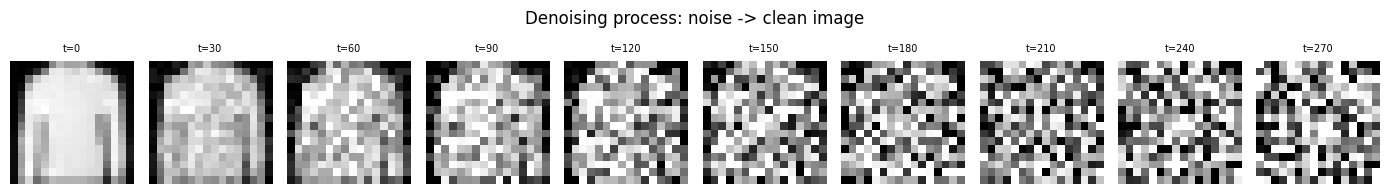

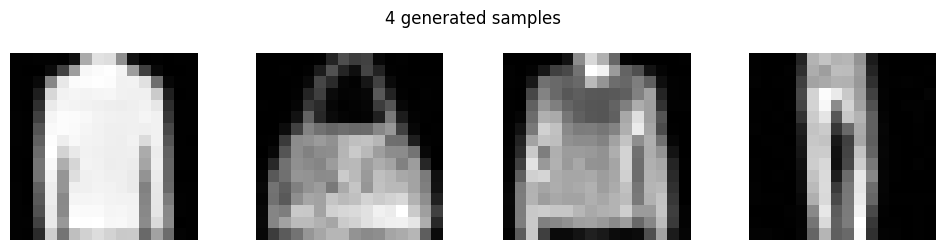

Model saved to unet_50epochs.pth
Upload this file to Google Drive/workshop_diffusion/


In [ ]:
# Train model_opt50: same architecture, 50 epochs
# Run this before the workshop (~17 minutes on T4)
# Then upload unet_50epochs.pth to Google Drive/workshop_diffusion/

model_opt50 = UNetOptimized(T).to(device)
optimizer_50 = Adam(model_opt50.parameters(), lr=0.001)
EPOCHS_50 = 50

model_opt50.train()
for epoch in range(EPOCHS_50):
    epoch_loss = 0
    for step, batch in enumerate(dataloader):
        optimizer_50.zero_grad()
        x_0  = batch[0].to(device)
        t    = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
        x_noisy, noise = q(x_0, t)
        loss = F.mse_loss(noise, model_opt50(x_noisy, t))
        loss.backward()
        optimizer_50.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS_50} | loss: {epoch_loss/len(dataloader):.5f}')

model_opt50.eval()
generate(model_opt50, n=4, show_steps=True)

torch.save(model_opt50.state_dict(), 'unet_50epochs.pth')

In [ ]:
# Download
from google.colab import files
files.download('unet_50epochs.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/BestCourse2026/workshop-genai', exist_ok=True)
torch.save(model_opt50.state_dict(), '/content/drive/MyDrive/BestCourse2026/workshop-genai/unet_50epochs.pth')
print('Saved to Google Drive: BestCourse2026/workshop-genai/unet_50epochs.pth')

Mounted at /content/drive
Saved to Google Drive: BestCourse2026/workshop-genai/unet_50epochs.pth


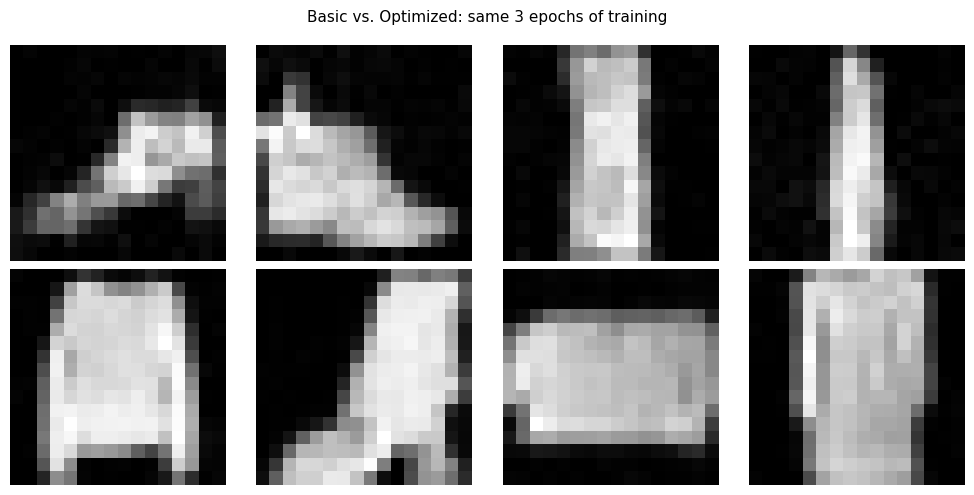

In [16]:
# Side-by-side comparison: basic model vs. optimized model
# Both trained for 3 epochs on the same dataset

@torch.no_grad()
def get_samples(model, n=4):
    results = []
    for _ in range(n):
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
        for i in range(T - 1, -1, -1):
            t_b = torch.full((1,), i, device=device).float()
            x   = reverse_q(x, t_b, model(x, t_b))
        results.append(((x[0]+1)/2).clamp(0,1).squeeze().cpu())
    return results

model_basic.eval()
model_opt3.eval()

n = 4
samples_basic = get_samples(model_basic, n)
samples_opt   = get_samples(model_opt3,   n)

fig, axes = plt.subplots(2, n, figsize=(10, 5))
for col in range(n):
    axes[0, col].imshow(samples_basic[col], cmap='gray')
    axes[0, col].axis('off')
    axes[1, col].imshow(samples_opt[col],   cmap='gray')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Basic\n(Conv+BN+ReLU\nMaxPool)', fontsize=8)
axes[1, 0].set_ylabel('Optimized\n(GELU+GroupNorm\nRearrange)', fontsize=8)
plt.suptitle('Basic vs. Optimized: same 3 epochs of training', fontsize=11)
plt.tight_layout()
plt.show()

### Pre-trained Model: 50 Epochs

The 3-epoch model shows the improvement in architecture.
But 3 epochs is still very little training.
Real diffusion models train for 100 to 500 epochs.

Below we load a pre-trained model (50 epochs, trained before the workshop)
from Google Drive and add it to the comparison.
This shows what the same architecture produces with more training time.

> **Before the workshop:** train UNetOptimized for 50 epochs and save to Drive:
> ```python
> torch.save(model_opt.state_dict(), 'unet_50epochs.pth')
> ```
> Then upload `unet_50epochs.pth` to your Google Drive.

Mounted at /content/drive
Pre-trained model loaded.


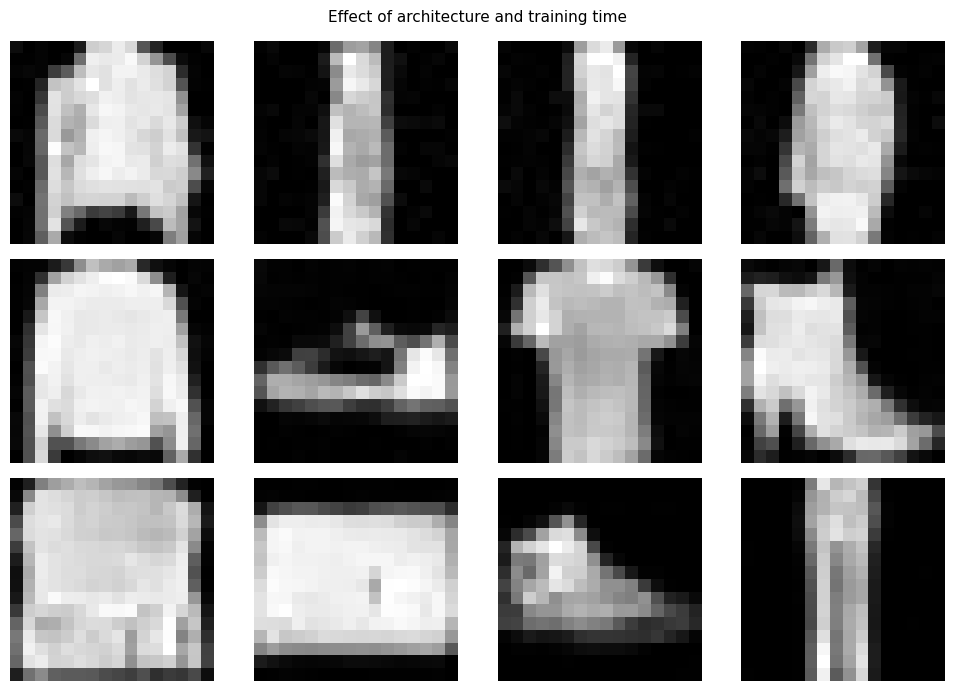

In [17]:
# Mount Google Drive and load the pre-trained 50-epoch model
from google.colab import drive
drive.mount('/content/drive')

# --- Placeholder: update this path to match your Drive folder ---
PRETRAINED_PATH = '/content/drive/MyDrive/BestCourse2026/workshop-genai/unet_50epochs.pth'

model_opt50 = UNetOptimized(T).to(device)
model_opt50.load_state_dict(torch.load(PRETRAINED_PATH, map_location=device))
model_opt50.eval()
print('Pre-trained model loaded.')

# --- Three-way comparison ---
n = 4
samples_basic = get_samples(model_basic,  n)
samples_3ep   = get_samples(model_opt3,   n)
samples_50ep  = get_samples(model_opt50,  n)

fig, axes = plt.subplots(3, n, figsize=(10, 7))
labels = [
    'Basic\n3 epochs\n(Conv+BN+ReLU)',
    'Optimized\n3 epochs\n(live trained)',
    'Optimized\n50 epochs\n(pre-trained)',
]
for row, (samples, label) in enumerate(zip(
    [samples_basic, samples_3ep, samples_50ep], labels
)):
    for col in range(n):
        axes[row, col].imshow(samples[col], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=8)

plt.suptitle('Effect of architecture and training time', fontsize=11)
plt.tight_layout()
plt.show()

---

## Practice Time (30 min)

Now it's your turn. Try to write each piece yourself before checking the solution.

### Task 1: `reverse_q`

Without looking at the demo code above, write the reverse diffusion step again.

In [18]:
@torch.no_grad()
def reverse_q_task(x_t, t, e_t):
    """
    One step of reverse diffusion.
    x_t : noisy image at timestep t,      shape [B, C, H, W]
    t   : current timestep per sample,    shape [B] (all same value)
    e_t : predicted noise from the model, shape [B, C, H, W]
    Returns x_{t-1}: slightly less noisy image.
    """
    t_int = t.int()
    coeff        = pred_noise_coeff[t_int, None, None, None]
    sqrt_a_inv_t = sqrt_a_inv[t_int, None, None, None]
    # FILL_IN: combine x_t, e_t, coeff, and sqrt_a_inv_t
    u_t = FILL_IN

    if t_int[0] == 0:
        return u_t
    else:
        B_prev = B[t_int - 1, None, None, None]
        return u_t + torch.sqrt(B_prev) * torch.randn_like(x_t)

print('reverse_q_task defined.')


reverse_q_task defined.


<details>
<summary><b>Click to show the solution</b></summary>

```python
u_t = sqrt_a_inv_t * (x_t - coeff * e_t)
```
</details>

### Task 2: `GELUConvBlock`

Without looking at the demo code above, write `GELUConvBlock` again: Conv2d, then GroupNorm, then GELU.

In [19]:
class GELUConvBlockTask(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        # FILL_IN: Conv2d(in_ch, out_ch, 3, 1, 1) + GroupNorm(group_size, out_ch) + GELU
        self.model = FILL_IN

    def forward(self, x):
        return self.model(x)

print('GELUConvBlockTask defined.')


GELUConvBlockTask defined.


<details>
<summary><b>Click to show the solution</b></summary>

```python
self.model = nn.Sequential(
    nn.Conv2d(in_ch, out_ch, 3, 1, 1),
    nn.GroupNorm(group_size, out_ch),
    nn.GELU(),
)
```
</details>

### Task 3: `UpBlockOpt`

Now build the optimized version of `UpBlock`, using your `GELUConvBlockTask` from Task 2. Remember:
- `ConvTranspose2d` with kernel=2, stride=2 (not kernel=3) so there is no checkerboard artifact
- four `GELUConvBlockTask` layers after the transposed convolution (not plain Conv layers)
- concatenate the skip connection first, same as before

In [20]:
class UpBlockOptTask(nn.Module):
    def __init__(self, in_ch, out_ch, group_size=8):
        super().__init__()
        self.model = nn.Sequential(
            # FILL_IN: ConvTranspose2d with kernel=2, stride=2 (no padding needed)
            FILL_IN,
            GELUConvBlockTask(out_ch, out_ch, group_size),
            GELUConvBlockTask(out_ch, out_ch, group_size),
            GELUConvBlockTask(out_ch, out_ch, group_size),
            GELUConvBlockTask(out_ch, out_ch, group_size),
        )

    def forward(self, x, skip):
        # FILL_IN: concatenate x and skip along the channel dimension, then pass through self.model
        return FILL_IN

print('UpBlockOptTask defined.')


UpBlockOptTask defined.


<details>
<summary><b>Click to show the solution</b></summary>

```python
nn.ConvTranspose2d(2 * in_ch, out_ch, 2, 2)
...
return self.model(torch.cat((x, skip), dim=1))
```
</details>

### Task 4: Put It Together

Use your `UpBlockOptTask` to complete `MiniUNetOpt` below (same architecture as `UNetOptimized`), train it for 1 epoch, then generate a few samples with your `reverse_q_task`. Compare visually with the basic model from the demo.

In [21]:
class MiniUNetOpt(nn.Module):
    """Same architecture as UNetOptimized, but using your UpBlockOptTask."""
    def __init__(self, T, img_ch=IMG_CH, down_chs=(32, 64, 128), t_embed_dim=8):
        super().__init__()
        self.T   = T
        up_chs   = down_chs[::-1]
        lat_size = IMG_SIZE // 4
        gs_sm    = 8
        gs_bg    = 32

        self.down0 = ResidualConvBlock(img_ch, down_chs[0], gs_sm)
        self.down1 = DownBlockOpt(down_chs[0], down_chs[1], gs_sm)
        self.down2 = DownBlockOpt(down_chs[1], down_chs[2], gs_bg)
        self.to_vec = nn.Sequential(nn.Flatten(), nn.GELU())

        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2] * lat_size**2, down_chs[1]), nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),                nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2] * lat_size**2),  nn.ReLU(),
        )

        self.sintime = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_emb1  = EmbedBlockOpt(t_embed_dim, up_chs[0])
        self.t_emb2  = EmbedBlockOpt(t_embed_dim, up_chs[1])

        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], lat_size, lat_size)),
            GELUConvBlock(up_chs[0], up_chs[0], gs_bg),
        )
        # FILL_IN: instantiate your UpBlockOptTask twice, same channel pattern as the demo
        self.up1 = FILL_IN
        self.up2 = FILL_IN

        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.GroupNorm(gs_sm, up_chs[-1]), nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_ch, 3, 1, 1),
        )

    def forward(self, x, t):
        t_sin = self.sintime(t.float() / self.T)
        t1    = self.t_emb1(t_sin)
        t2    = self.t_emb2(t_sin)

        d0    = self.down0(x)
        d1    = self.down1(d0)
        d2    = self.down2(d1)
        lat   = self.dense_emb(self.to_vec(d2))

        u0    = self.up0(lat)
        u1    = self.up1(t1 * u0, d2)
        u2    = self.up2(t2 * u1, d1)
        return self.out(torch.cat((u2, d0), dim=1))


# Sanity check
model_task = MiniUNetOpt(T).to(device)
x_test = torch.randn(2, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)
t_test = torch.tensor([50., 150.]).to(device)
print(f'Output shape: {model_task(x_test, t_test).shape}')


Output shape: torch.Size([2, 1, 16, 16])


<details>
<summary><b>Click to show the solution</b></summary>

```python
self.up1 = UpBlockOptTask(up_chs[0], up_chs[1], gs_bg)
self.up2 = UpBlockOptTask(up_chs[1], up_chs[2], gs_sm)
```
</details>

Epoch 1/1 | loss: 0.12784


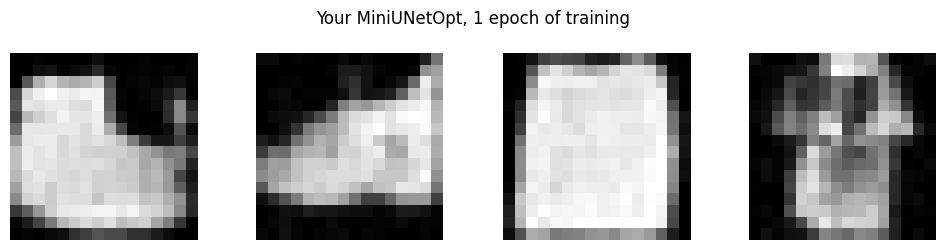

In [22]:
# Quick training: 1 epoch is enough to see a difference from an untrained model
optimizer_task = Adam(model_task.parameters(), lr=0.001)

model_task.train()
epoch_loss = 0
for step, batch in enumerate(dataloader):
    optimizer_task.zero_grad()
    x_0  = batch[0].to(device)
    t    = torch.randint(0, T, (BATCH_SIZE,), device=device).float()
    x_noisy, noise = q(x_0, t)
    loss = F.mse_loss(noise, model_task(x_noisy, t))
    loss.backward()
    optimizer_task.step()
    epoch_loss += loss.item()
print(f'Epoch 1/1 | loss: {epoch_loss/len(dataloader):.5f}')

model_task.eval()

@torch.no_grad()
def get_samples_task(model, n=4):
    results = []
    for _ in range(n):
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
        for i in range(T - 1, -1, -1):
            t_b = torch.full((1,), i, device=device).float()
            x   = reverse_q_task(x, t_b, model(x, t_b))
        results.append(((x[0]+1)/2).clamp(0,1).squeeze().cpu())
    return results

n = 4
samples_task = get_samples_task(model_task, n)

fig, axes = plt.subplots(1, n, figsize=(10, 2.5))
for col in range(n):
    axes[col].imshow(samples_task[col], cmap='gray')
    axes[col].axis('off')
plt.suptitle('Your MiniUNetOpt, 1 epoch of training')
plt.tight_layout()
plt.show()


---

## Wrapping Up

In this notebook you have:

- Implemented the reverse diffusion process (`reverse_q`) and the sampling loop
- Generated images with the basic model and observed pixelation and checkerboard artifacts
- Replaced BatchNorm + ReLU with GroupNorm + GELU (GELUConvBlock)
- Replaced MaxPool with RearrangePoolBlock to avoid information loss
- Added sinusoidal time embeddings for richer timestep representation
- Added residual connections for better gradient flow (ResidualConvBlock)
- Trained the fully optimized model and compared the results

**Key points:**

- The checkerboard artifact is fixed by using `ConvTranspose2d(kernel=2, stride=2)`
  instead of `(kernel=3, stride=2)`. No overlap means no checkerboard.
- RearrangePoolBlock preserves all spatial information, unlike MaxPool.
- Sinusoidal embeddings give the model a unique, multi-scale representation of each timestep.
- With 5 epochs the results are still not photorealistic.
  Real diffusion models train for hundreds of epochs on large GPU clusters.

**Part 3** adds class conditioning and CLIP conditioning
so the model can generate specific clothing categories and respond to text descriptions.

In [ ]:
# Run this cell before opening the Part 3 notebook
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)